<a href="https://colab.research.google.com/github/ktgirl38/CSC-402/blob/main/Group_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb #import seaborn sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/DSC502ProjectData/v20.meta.per_cell_line.txt', sep='\t')


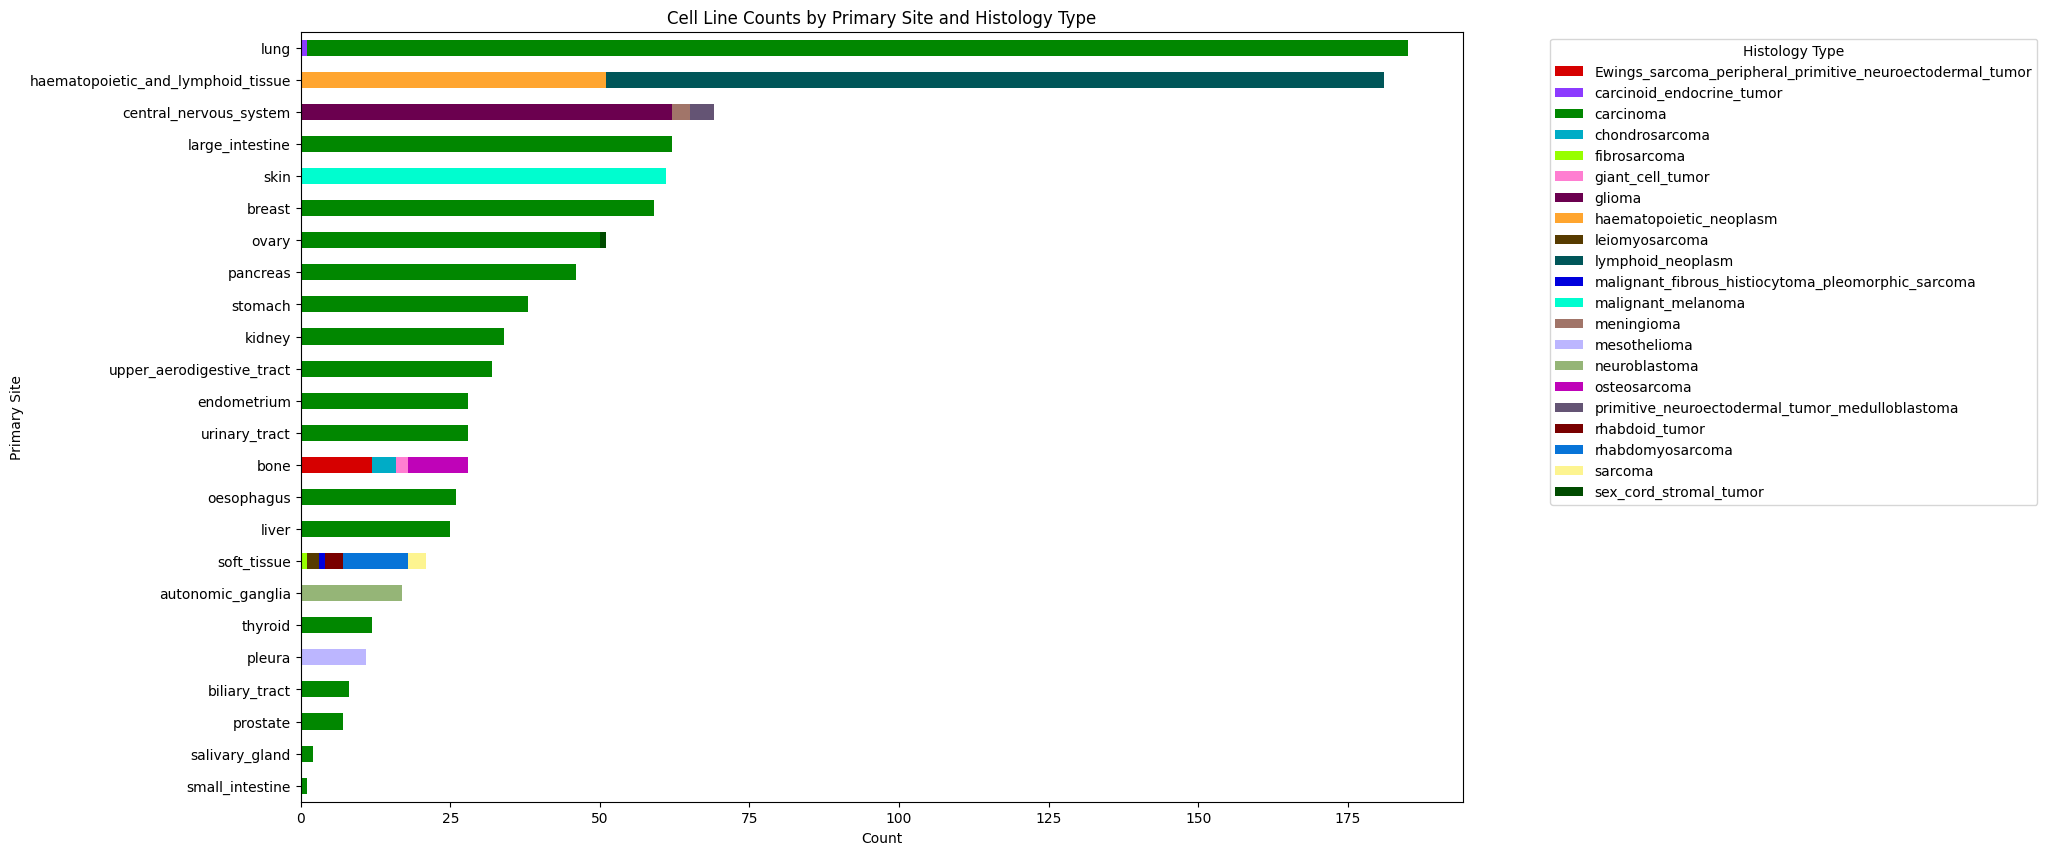

In [ ]:
import matplotlib.colors as cm
import colorcet as cc

df2=df.groupby(['ccle_primary_site', 'ccle_primary_hist']).size().reset_index()
pt=pd.pivot_table(df2, values=0, index='ccle_primary_site', columns='ccle_primary_hist', fill_value=0)
pt['total'] = pt.sum(axis=1)
pt = pt.sort_values('total', ascending=True)
pt = pt.drop(columns='total')

palette = sb.color_palette(cc.glasbey, n_colors=21)
selected_colormap = cm.ListedColormap(palette)

pt.plot(kind='barh', stacked=True, legend='Upper Right', figsize=(15, 10), colormap=selected_colormap)
plt.title('Cell Line Counts by Primary Site and Histology Type')
plt.xlabel('Count')
plt.xticks(rotation=0)
plt.ylabel('Primary Site')
plt.legend(loc='upper right', bbox_to_anchor=(1.5, 1), title='Histology Type')


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/DSC502ProjectData/v20.data.curves_post_qc.txt', sep='\t')
df_meta = pd.read_csv('/content/drive/MyDrive/DSC502ProjectData/v20.meta.per_compound.txt', sep='\t')
df_exp=pd.read_csv('/content/drive/MyDrive/DSC502ProjectData/v20.meta.per_experiment.txt', sep='\t')
df_cell=pd.read_csv('/content/drive/MyDrive/DSC502ProjectData/v20.meta.per_cell_line.txt', sep='\t')


df_merged = pd.merge(df, df_meta[['master_cpd_id', 'cpd_name']], on='master_cpd_id')
df_merged = pd.merge(df_merged, df_exp[['experiment_id','growth_mode','culture_media','master_ccl_id']], on='experiment_id')
df_merged = pd.merge(df_merged, df_cell[['master_ccl_id', 'ccle_primary_site', 'ccle_hist_subtype_1', 'ccle_primary_hist']], on='master_ccl_id')

In [ ]:
df_merged['p4_baseline'].head()

,p4_baseline
0,-0.2345
1,0.4412
2,1.1650
3,0.8505
4,0.0253


In [ ]:
df_sorted=df_merged.groupby('cpd_name', as_index=True).agg({'area_under_curve': 'median'})
df_sorted=df_sorted['area_under_curve'].sort_values(ascending=True)

df_merged.to_csv('data_merged.csv')

print(df_sorted[:5])

highest_five_aucs = pd.merge(df_sorted[:5], df_merged, left_index=True, how="inner", right_on="cpd_name")


cpd_name
leptomycin B    3.59865
dinaciclib      5.15185
ouabain         5.32790
LBH-589         5.42150
SB-743921       5.91930
Name: area_under_curve, dtype: float64


Text(0.5, 1.0, 'Percentage of Viable Cancer Cells Remaining\n After Maximum Compound Dosage')

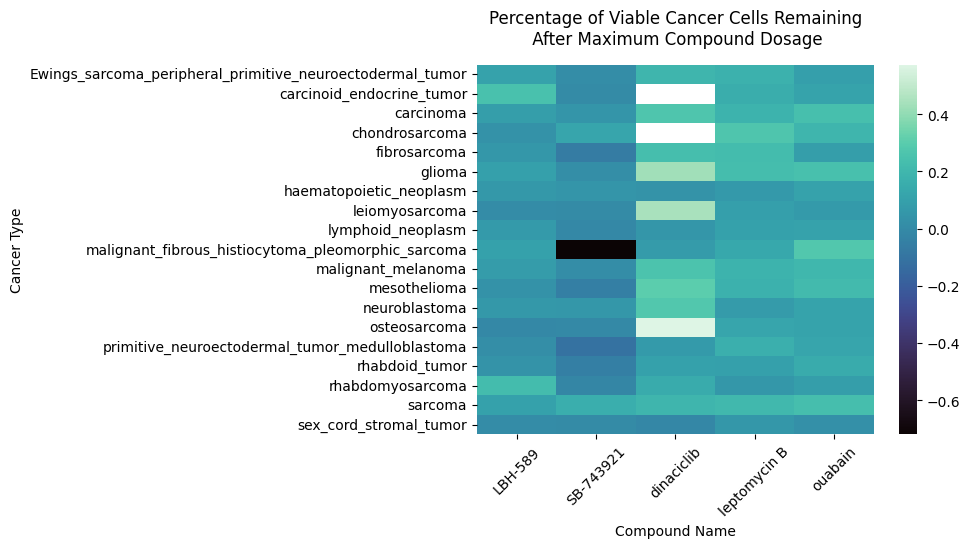

In [ ]:
df_heatmap = highest_five_aucs.pivot_table(index='ccle_primary_hist', columns='cpd_name', values='p4_baseline')
sb.heatmap(df_heatmap, cmap='mako')
x_ticks = plt.xticks(rotation=45)
plt.xlabel("Compound Name")
plt.ylabel("Cancer Type")
plt.title("Percentage of Viable Cancer Cells Remaining\n After Maximum Compound Dosage", pad=15)

Text(0.5, 1.0, 'Percentage of Viable Cancer Cells Remaining\n After Maximum Compound Dosage')

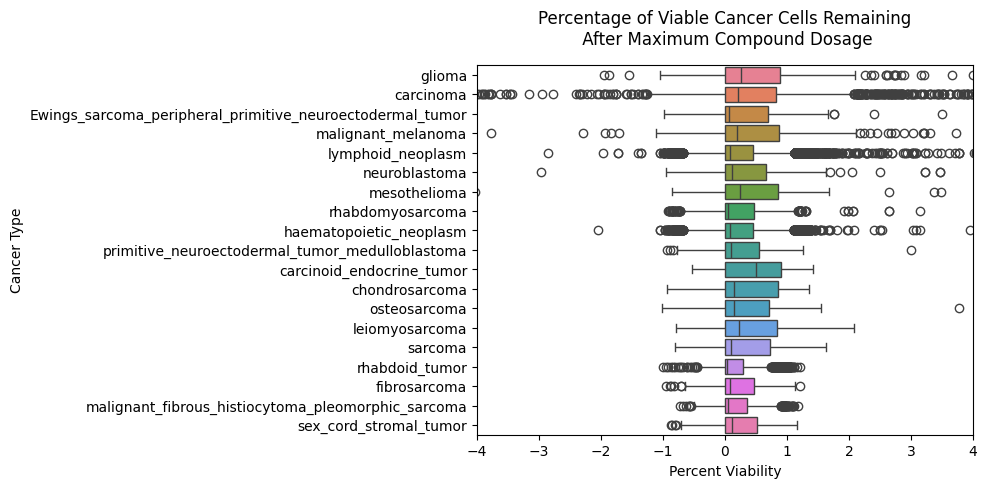

In [ ]:
plot=sb.boxplot(df_merged, y='ccle_primary_hist', x='p4_baseline', hue='ccle_primary_hist')
plot.set_xlim(-4, 4)
plot.legend().remove()
plot.set_xlabel("Percent Viability")
plot.set_ylabel("Cancer Type")
plot.set_title("Percentage of Viable Cancer Cells Remaining\n After Maximum Compound Dosage", pad=15)

Text(0.5, 1.03, 'Predicted High-Dose Viability vs. Actual Maximum Dose Viability')

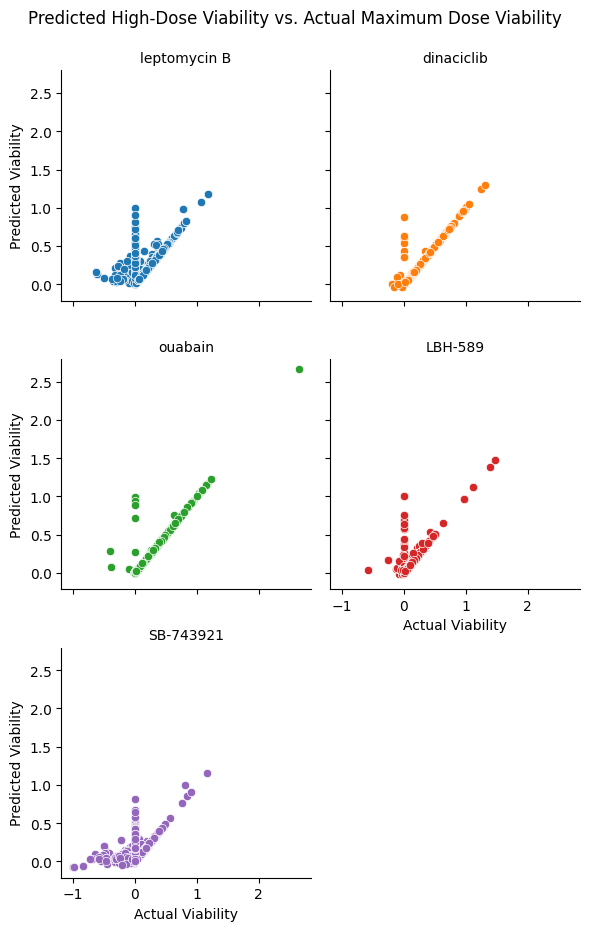

In [ ]:

g=sb.FacetGrid(highest_five_aucs, col='cpd_name', col_wrap=2, hue='cpd_name')
g.map(sb.scatterplot, 'p4_baseline', 'pred_pv_high_conc')
g.set_xlabels('Actual Viability')
g.set_ylabels('Predicted Viability')
g.set_titles(col_template="{col_name}")
g.fig.suptitle('Predicted High-Dose Viability vs. Actual Maximum Dose Viability', y=1.03)